In [48]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import dotenv
import operator

In [49]:
dotenv.load_dotenv()

True

In [50]:
class state(TypedDict):
    essay: str
    lang_feedback: str
    cot_feedback: str
    doa_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    final_score: float
    final_feedback: str

In [51]:
essay = """
    I. Introduction to AI technology and its rapid advancement

        Artificial Intelligence (AI) is a revolutionary technology that has been rapidly advancing in recent years. AI involves the development of computer systems that can perform tasks that typically require human intelligence, such as decision-making, problem-solving, and pattern recognition. With advancements in machine learning, neural networks, and natural language processing, AI has become increasingly integrated into various aspects of society, from business operations to healthcare to entertainment.

    II. Positive impacts of AI on society

        One of the major positive impacts of AI on society is increased productivity and efficiency. AI-powered systems are capable of handling large amounts of data at a much faster rate than humans, leading to faster and more accurate decision-making. This has the potential to streamline processes and improve overall productivity in industries such as manufacturing, finance, and healthcare. Additionally, AI technologies can also enhance the quality of products and services by analyzing consumer behavior and preferences to tailor offerings to individual customers.

    III. Negative impacts of AI on society

        Despite the many benefits of AI, there are also negative impacts that should be considered. One of the main concerns is job displacement. As AI technology becomes more advanced, the need for human workers in certain industries may decrease, leading to job loss and economic insecurity for those affected. Additionally, there are ethical concerns surrounding the use of AI, particularly in areas such as data privacy, bias in algorithms, and the potential for misuse of AI technology for malicious purposes.

    In conclusion, AI technology has the potential to bring about significant positive changes in society, such as increased productivity and efficiency. However, it is important to address the negative impacts of AI, including job displacement and ethical concerns, in order to ensure that the benefits of this technology are realized in a responsible and equitable manner.
    
    Score: 8
    Evaluation: This content provides a comprehensive overview of AI technology, discussing both the positive impacts on society such as increased productivity and efficiency, as well as the negative impacts such as job displacement and ethical concerns. The content is well-organized and presents a balanced perspective on the topic. It would have been helpful to provide more specific examples of the positive and negative impacts of AI on society to further illustrate the points made. Overall, a solid introduction to the topic of AI technology and its implications on society.
"""

In [52]:
graph = StateGraph(state)

In [53]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay, highlighting strengths and areas for improvement.")
    score: int = Field(description="A score between 0 and 10")

In [54]:
model = ChatOpenAI(model="gpt-4o")
model_structured = model.with_structured_output(EvaluationSchema)

In [55]:
# Define the nodes
def language_feedback_node(state: state) -> state:
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    feedback = model_structured.invoke(prompt)
    
    return {
        "lang_feedback": feedback.feedback,
        "individual_scores": [feedback.score]
    }

def cot_feedback_node(state: state) -> state:
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    feedback = model_structured.invoke(prompt)
    
    return {
        "cot_feedback": feedback.feedback,
        "individual_scores": [feedback.score]
    }

def doa_feedback_node(state: state) -> state:
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    feedback = model_structured.invoke(prompt)
    
    return {
        "doa_feedback": feedback.feedback,
        "individual_scores": [feedback.score]
    }

def final_evaluation_node(state: state) -> state:
    final_score = sum(state["individual_scores"]) / len(state["individual_scores"])
    feedback = f"Final Score: {final_score}\n\nLanguage Feedback: {state['lang_feedback']}\n\nClarity of Thought Feedback: {state['cot_feedback']}\n\nDepth of Analysis Feedback: {state['doa_feedback']}"
    
    return {
        "final_score": final_score,
        "final_feedback": feedback
    }

In [56]:
# Add nodes
graph.add_node("language_feedback_node", language_feedback_node)
graph.add_node("clarity_of_thought_feedback_node", cot_feedback_node)
graph.add_node("depth_of_analysis_feedback_node", doa_feedback_node)
graph.add_node("final_evaluation_node", final_evaluation_node)

In [57]:
# Add edges and their corresponding functions
graph.add_edge(START, "language_feedback_node")
graph.add_edge(START, "clarity_of_thought_feedback_node")
graph.add_edge(START, "depth_of_analysis_feedback_node")

graph.add_edge("language_feedback_node", "final_evaluation_node")
graph.add_edge("clarity_of_thought_feedback_node", "final_evaluation_node")
graph.add_edge("depth_of_analysis_feedback_node", "final_evaluation_node")
graph.add_edge("final_evaluation_node", END)

workflow =  graph.compile()

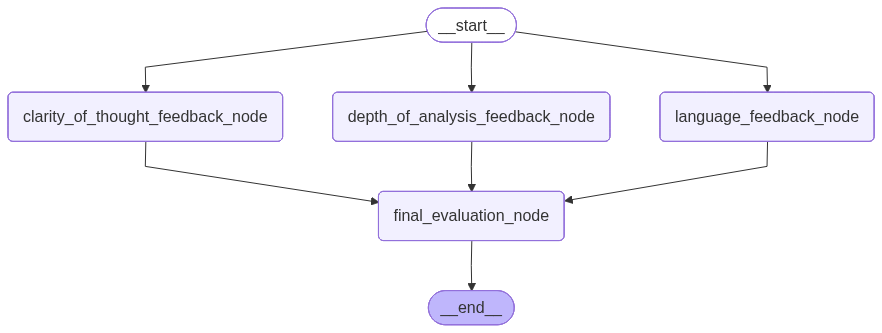

In [58]:
workflow

In [60]:
intial_state = {
    'essay': essay
}

final_state = workflow.invoke(intial_state)

print(final_state["final_score"])

8.0
